## Importing

In [88]:
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For statistical data visualization

from sklearn.model_selection import train_test_split  # To split the data into training and test sets
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # For scaling and encoding features
from sklearn.compose import ColumnTransformer  # To apply transformations to specific columns
from sklearn.pipeline import Pipeline  # To create pipelines for preprocessing steps
from sklearn.impute import SimpleImputer  # To handle missing values


import tensorflow as tf
from tensorflow.keras import Sequential  # For creating the neural network model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization  # For model layers and regularization
from tensorflow.keras.layers import Dropout  # Importing Dropout for regularization
from tensorflow.keras.callbacks import EarlyStopping  # Importing EarlyStopping
from tensorflow.keras.regularizers import l2  # Importing L2 regularization

import os
import joblib

In [39]:
print(os.listdir(os.getcwd()))

['.config', 'Telco_Cusomer_Churn.csv', 'sample_data']


In [ ]:
# read dataset
df = pd.read_csv('Telco_Customer_Churn.csv')

In [41]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [42]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [43]:
df.drop('customerid', axis=1, inplace=True)

In [44]:
df['churn'] = df['churn'].replace({'Yes':1, 'No':0})

/tmp/ipython-input-1512796522.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['churn'] = df['churn'].replace({'Yes':1, 'No':0})


In [45]:
df['seniorcitizen'] = df['seniorcitizen'].replace({1:'Yes', 0:'No'})
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   object 
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprotection  7043 non-null   object 
 11  techsupport       7043 non-null   object 
 12  streamingtv       7043 non-null   object 
 13  streamingmovies   7043 non-null   object 
 14  contract          7043 non-null   object 
 15  paperlessbilling  7043 non-null   object 
 16  paymentmethod     7043 non-null   object 


In [47]:
df.isna().sum()

,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0
onlinebackup,0


In [48]:
df.describe()

,tenure,monthlycharges,totalcharges,churn
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,0.265370
std,24.559481,30.090047,2266.771362,0.441561
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3794.737500,1.000000
max,72.000000,118.750000,8684.800000,1.000000


In [49]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male']
seniorcitizen: ['No' 'Yes']
partner: ['Yes' 'No']
dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
phoneservice: ['No' 'Yes']
multiplelines: ['No phone service' 'No' 'Yes']
internetservice: ['DSL' 'Fiber optic' 'No']
onlinesecurity: ['No' 'Yes' 'No internet service']
onlinebackup: ['Yes' 'No' 'No internet service']
deviceprotection: ['No' 'Yes' 'No internet service']
techsupport: ['No' 'Yes' 'No internet service']
streamingtv: ['No' 'Yes' 'No internet service']
streamingmovies: ['No' 'Yes' 'No internet service']
contract: ['Month-to-month' 'One year' 'Two year']
paperlessbilling: ['Yes' 'No']
paymentmethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
monthlycharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
to

In [50]:
# Split the data
X = df.drop('churn', axis=1)
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check shapes
print('X_train.shape \t', x_train.shape)
print('y_train.shape \t', y_train.shape)
print('***'*10)
print('X_test.shape \t', x_test.shape)
print('y_test.shape \t', y_test.shape)

X_train.shape 	 (5634, 19)
y_train.shape 	 (5634,)
******************************
X_test.shape 	 (1409, 19)
y_test.shape 	 (1409,)


In [51]:
numerical_features = ['tenure','monthlycharges', 'totalcharges' ]
categorical_features = ['gender','multiplelines','internetservice','contract', 'onlinesecurity', 'onlinebackup','deviceprotection','techsupport','streamingtv','streamingmovies', 'paymentmethod']
ready_features = list(set(x_train.columns.tolist()) - set(numerical_features) - set(categorical_features))



In [52]:
# get unique value
for col in numerical_features:
    print(f"{col}: {x_train[col].unique()}")

tenure: [35 15 13 26  1 66 40 65 60  5  2 30 36 55 31 28 16  6 27 58 72 12 71  3
 25 52 46  9 19 45 38 10 18 37 11 64 48 20 69 63 39  4 53 51 61  8 24 14
 68 23  7 32 56 43 29 67 50 59 21 47 41 34 57 33 44 70 49 22 42 62 54 17
  0]
monthlycharges: [ 49.2   75.1   40.55 ...  56.8   46.05 102.8 ]
totalcharges: [1701.65 1151.55  590.35 ...   80.35 2660.2   109.3 ]


In [53]:
numerical_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


ready_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder())
])


# Combine all pipelines using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipline, numerical_features),
    ('cat', categorical_pipeline, categorical_features),
    ('ready', ready_pipeline, ready_features)
])

# Fit and transform the training data
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)




In [54]:
#handling unbalanced classes
from imblearn.over_sampling import SMOTE
over = SMOTE(k_neighbors=5, sampling_strategy=0.7, random_state=45)
X_train_processed_resampled, y_train_resampled = over.fit_resample(x_train_processed, y_train)

## Building ANN

In [124]:
early_stop = EarlyStopping(
    monitor='val_loss',      # What to monitor (val_loss is most common)
    patience=10,              # Number of epochs with no improvement before stopping
    restore_best_weights=True  # Roll back to best model
)


In [125]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_processed_resampled.shape[1],)),  # First hidden layer with 128 neurons
    Dense(64, activation='relu'),  # Second hidden layer with 64 neurons
    Dense(32, activation='relu'),  # Third hidden layer with 32 neurons
    Dense(16, activation='relu'),  # Fourth hidden layer with 16 neurons
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

In [126]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [127]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 128)            │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
history = model.fit(X_train_processed_resampled, y_train_resampled, epochs=100, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stop])

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7366 - loss: 0.5153 - val_accuracy: 0.6342 - val_loss: 0.8474
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8048 - loss: 0.4207 - val_accuracy: 0.5298 - val_loss: 0.9008
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8037 - loss: 0.4103 - val_accuracy: 0.5817 - val_loss: 0.7967
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8137 - loss: 0.4043 - val_accuracy: 0.6584 - val_loss: 0.6507
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8142 - loss: 0.3999 - val_accuracy: 0.6278 - val_loss: 0.7053
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8160 - loss: 0.3973 - val_accuracy: 0.5149 - val_loss: 0.8604
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8177 - loss: 0.4054 - val_accuracy: 0.6335 - val_loss: 0.6976
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8187 - loss: 0.3912 - val_acc

### Evaluation

In [129]:
# Evaluating the overfitted model on the test data
test_loss, test_accuracy = model.evaluate(x_test_processed, y_test)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7465 - loss: 1.2423
Test Loss : 1.2401
Test Accuracy : 0.7551


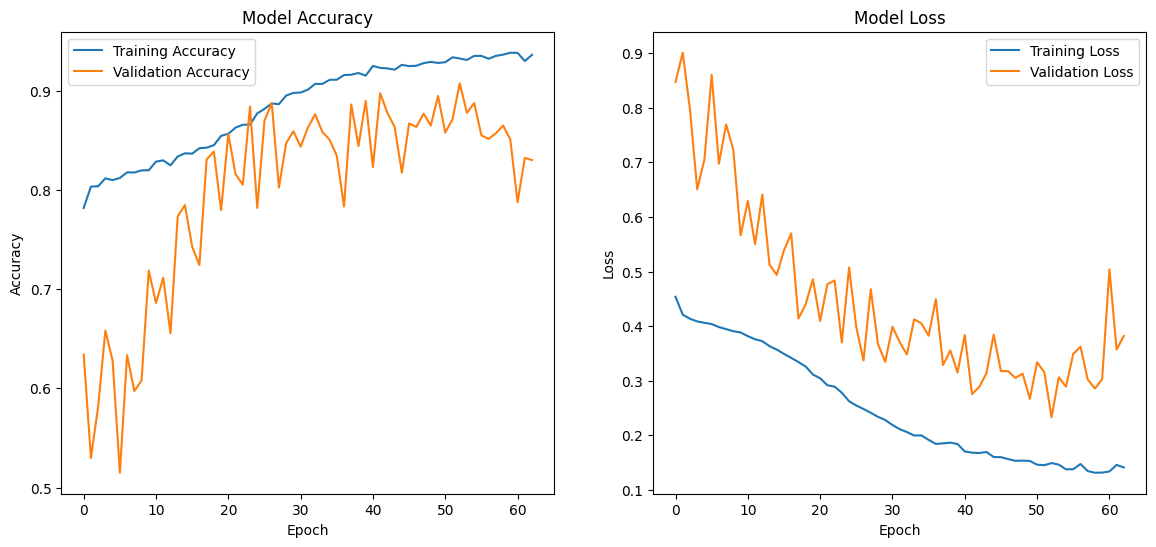

In [130]:
# Plotting training and validation accuracy for the overfitted model
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss for the overfitted model
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [131]:
# model Dump
joblib.dump(model, 'ANN_model.joblib')

['ANN_model.joblib']